# Digital Biomarkers Project

The goal of this project is to develop a pipeline for analyzing breast ultrasound images, extracting meaningful features, and classifying tumors into benign or malignant categories. By leveraging medical imaging, feature extraction, and machine learning, the project demonstrates the practical applications of digital biomarkers in personalized healthcare.

Tasks:

- Data Preparation: Organizing ultrasound images and masks for analysis.
- Feature Extraction: Deriving numerical descriptors of tumor properties.
- Classification: Using machine learning to predict tumor type based on extracted features.

## Step 1: Data Preparation
The first step is to prepare a clean, structured dataset of benign and malignant tumor images and segmentation masks.

For this, I download the dataset, try to understand its structure, and preprocessing it for analysis. Using the csv provided, I read the image into four lists: benignant, malignant and the  corresponding segmentation mask, which identifies the tumor's location within the ultrasound image. 
The images are visualized to ensure correctness and alignment between the ultrasound image and its mask.

## Imports

In [1]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from typing import List, Tuple

## Lecture / Demonstration

### Functions
Here I define a function to describe the image we import.

In [2]:
def describe_image(image):
    print("Image dimensions: ", image.shape)
    print("Image type: ", image.dtype)
    print("Image min/max: ", image.min(), image.max())

### Grayscale Image
We load an image of different gray rectangles using plt.imread() and save it into the variable rectangles.

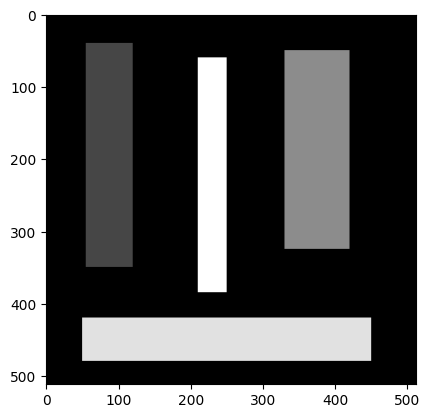

In [3]:
rectangles = plt.imread('rectangles.bmp')

plt.figure()
plt.imshow(rectangles, cmap='gray', vmin=-0, vmax=255) 
plt.show()

- cmap='gray': colormap -> ensures the image is displayed in grayscale
- vmin=0 / vmax=255: set the display range for pixel intensity values

In [13]:
describe_image(rectangles)

Image dimensions:  (512, 512)
Image type:  uint8
Image min/max:  0 255


### Darker Grayscale

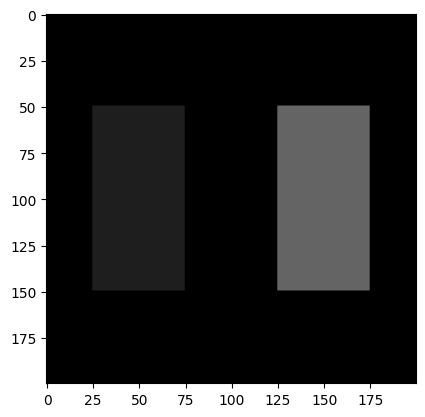

In [6]:
rectangles_darker = plt.imread('rectangles_darker.bmp')

plt.figure()
plt.imshow(rectangles_darker, cmap='gray', vmin=-0, vmax=255) 
plt.show()

In [14]:
describe_image(rectangles_darker)

Image dimensions:  (200, 200)
Image type:  uint8
Image min/max:  0 100


### RGB 

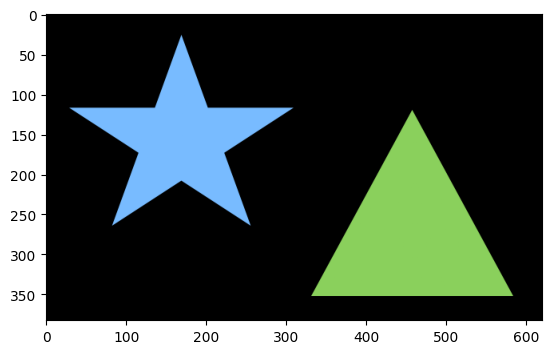

In [9]:
rgb = plt.imread('shapes_RGB.png')

plt.figure()
plt.imshow(rgb) 
plt.show()

In [15]:
describe_image(rgb)

Image dimensions:  (383, 621, 3)
Image type:  float32
Image min/max:  0.0 1.0


Here, we don't need a colormap or a vmin/vmax, because it is an RGB image.

## Project Week 1


### Loading the images
I will perform the following steps to load the images:
1. Paths: Define the paths to the benign, malignant, and normal folders
2. Initialize empty lists to store images and labels
3. Define a function to load the images and labels

#### 1. Paths
In the first step, I save the paths to the folders containing the different datasets to variables so I can use them later on.

In [21]:
base_dir = "../../Breast tumor/Dataset_BUSI_with_GT"
benign_dir = os.path.join(base_dir, "benign")
malignant_dir = os.path.join(base_dir, "malignant")
normal_dir = os.path.join(base_dir, "normal")

Then, I load the valid indices from the csv file. This file contains the indices of images and masks that are considered valid. Some are not, this seems to be due to text / other distractors that could interfere with the feature extraction. 

In [11]:
valid_indices_df = pd.read_csv('../../Breast tumor/Benign_malignant_indices.csv')

benign_indices = valid_indices_df['benign'].dropna().astype(int).tolist()
malignant_indices = valid_indices_df['malignant'].dropna().astype(int).tolist()

During initial analysis of the images, I realised we have images that contain several breast tumours in one image. This was visible because we had 

#### 2. Define a function to load the images and labels
With this function, I can load the images into the lists. We pass the category benign / malignant as an argument so we can use it to load both. The function returns two lists: the images and the corresponding masks.

Problems / Goals:
- seperate images and masks
- make sure only valid images are loaded (see the csv)
- later edit: make sure we have the same amount of masks and images. & only include images we want to keep -> in the valid list of benign images, there was the image 181 included, which contained several tumours/several masks. I assumed this was something we wanted to exclude and removed the image 181 and it's mask.

In [ ]:
exclude_benign = [181]
benign_indices = [index for index in benign_indices if index not in exclude_benign]

In [ ]:
def read_images(folder_path, category, valid_indices) -> Tuple[List[str], List[str]]:
    images = []
    masks = []

    for index in valid_indices:
            # Construct the filenames based on the index and category
            img_file_name = f"{category} ({index}).png"
            mask_file_name = f"{category} ({index})_mask.png"

            # Define the full file paths
            img_file_path = os.path.join(folder_path, img_file_name)
            mask_file_path = os.path.join(folder_path, mask_file_name)
            # Check if the files exist
            if not os.path.exists(img_file_path) or not os.path.exists(mask_file_path):
                raise FileNotFoundError(f"Image or mask file missing for index {index}")

            # Read the image and mask, and append them to the lists
            images.append(plt.imread(img_file_path)[:, :, 0])
            masks.append(plt.imread(mask_file_path))


    return images, masks


Here we call the function for both benign and malignant images.

In [ ]:
benign_images, benign_masks = read_images(benign_dir, 'benign', benign_indices)
malignant_images, malignant_masks = read_images(malignant_dir, 'malignant', malignant_indices)

../../Breast tumor/Dataset_BUSI_with_GT/benign/benign (1).png
../../Breast tumor/Dataset_BUSI_with_GT/benign/benign (1)_mask.png
../../Breast tumor/Dataset_BUSI_with_GT/benign/benign (3).png
../../Breast tumor/Dataset_BUSI_with_GT/benign/benign (3)_mask.png
../../Breast tumor/Dataset_BUSI_with_GT/benign/benign (7).png
../../Breast tumor/Dataset_BUSI_with_GT/benign/benign (7)_mask.png
../../Breast tumor/Dataset_BUSI_with_GT/benign/benign (8).png
../../Breast tumor/Dataset_BUSI_with_GT/benign/benign (8)_mask.png
../../Breast tumor/Dataset_BUSI_with_GT/benign/benign (10).png
../../Breast tumor/Dataset_BUSI_with_GT/benign/benign (10)_mask.png
../../Breast tumor/Dataset_BUSI_with_GT/benign/benign (12).png
../../Breast tumor/Dataset_BUSI_with_GT/benign/benign (12)_mask.png
../../Breast tumor/Dataset_BUSI_with_GT/benign/benign (15).png
../../Breast tumor/Dataset_BUSI_with_GT/benign/benign (15)_mask.png
../../Breast tumor/Dataset_BUSI_with_GT/benign/benign (16).png
../../Breast tumor/Dataset_B

#### 3. Check whether Images are correctly loaded
To verify the previous steps, I display the first item in each list.

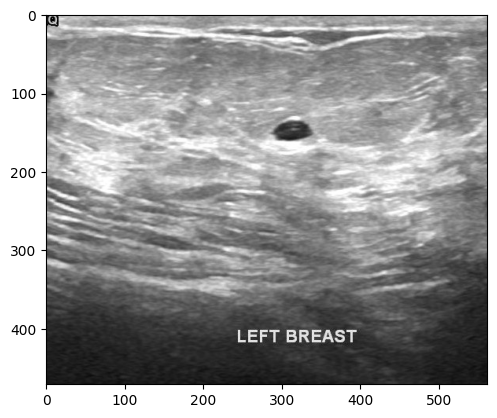

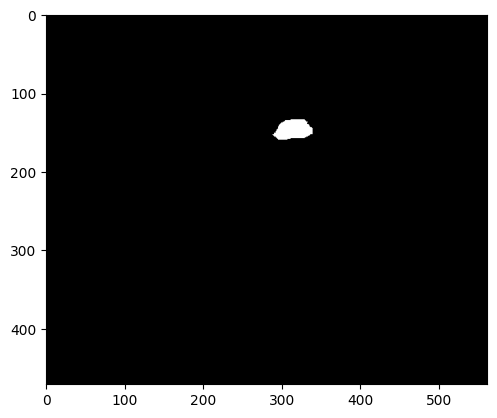

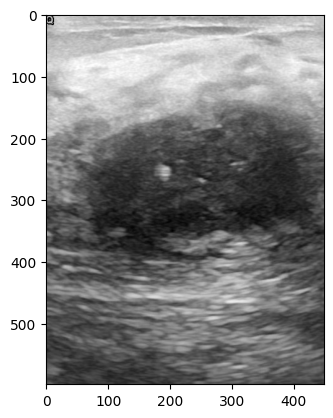

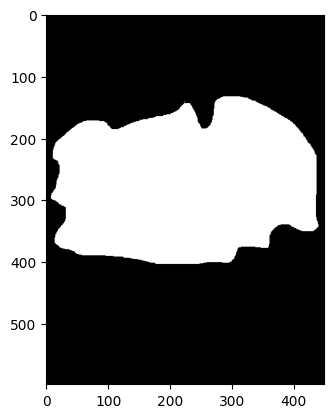

In [65]:
plt.figure()
plt.imshow(benign_images[0], cmap = "gray")
plt.figure()
plt.imshow(benign_masks[0], cmap = "gray")
plt.figure()
plt.imshow(malignant_images[0], cmap = "gray")
plt.figure()
plt.imshow(malignant_masks[0], cmap = "gray")

I also want to make sure I only loaded valid images. To do this, I compare the length of the valid indices benign / malignant with the length of the image lists.

In [33]:
print(len(valid_indices_df['benign']))
print(len(benign_images))
print(len(benign_masks))
print(len(valid_indices_df['malignant']))
print(len(malignant_images))
print(len(malignant_masks))

176
175
175
176
176
176


Here we can see that I now have one less image for the benign images (as I removed the one with the two tumours / masks). If necessary, I will later drop out one of the malignant images at random.

# Part 2: Feature Extraction
In this part, I try to extract science-based features from the images / masks.

## Shape Features
I try to extract the following features from the images:
- Area (Volume): number of pixels within tumor 
- Perimeter: this expresses the total surface of the tumor
- Circularity: round vs. irregular shaped?
- Regularity: how irregular is the "border" of the tumor

To calculate these geometric features, we can use the masks (and don't need the images themselves.)

### Area
The area describes the number of pixels contained in the tumor / mask. So we can return the sum of all values in the mask that are > 0.

In [35]:
def calculate_area(mask):
    return np.sum(mask > 0)


### Perimeter
Here, I calculate the boundary of the mask to get the surface of the tumor. 

In [36]:
def calculate_perimeter(mask):
    #to boolean array
    mask = mask > 0
    # Compute the boundary (edges) of the mask
    boundary = np.logical_xor(mask, np.pad(mask[:-1, :], ((1, 0), (0, 0)), mode='constant')) | \
               np.logical_xor(mask, np.pad(mask[:, :-1], ((0, 0), (1, 0)), mode='constant'))
    return np.sum(boundary)


### Circularity
Here we calculate the circularity of the tumor by comparing the tumor's area and perimeter. 
We compare the shape of our tumor to the perfect circle, because the perfect circle would have the smallest perimeter for a given area.
There is a formula to express this: 
Circularity = (4 * pi * area) / (perimeter^2)

The circularity of a perfect circle would be 1. The closer to one the circularity of our tumour is, the closer to a perfect circle (= the more round) it is.

In [37]:
def calculate_circularity(area, perimeter):
    if perimeter == 0: # this is to avoid dividing by zero
        return 0
    return (4 * np.pi * area) / (perimeter ** 2)

### Regularity
Here, we calculate how irregular the "border" of our tumour is. We do this by comparing the area of the tumor to the area of the smallest rectangle that fully surrounds the tumor (= bounding box). 


In [38]:
def calculate_regularity(mask):
    mask = mask > 0
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    bounding_box_area = (rows.sum() * cols.sum())
    if bounding_box_area == 0:
        return 0
    return np.sum(mask) / bounding_box_area

In [47]:
def extract_shape_features(masks):
    areas = []
    perimeters = []
    circularities = []
    regularities = []

    for mask in masks:
        area = calculate_area(mask)
        perimeter = calculate_perimeter(mask)
        circularity = calculate_circularity(area, perimeter)
        regularity = calculate_regularity(mask)

        areas.append(area)
        perimeters.append(perimeter)
        circularities.append(circularity)
        regularities.append(regularity)

    df = pd.DataFrame({
        'area': areas,
        'perimeter': perimeters,
        'circularity': circularities,
        'regularity': regularities
    })

    return df

In [48]:
benign_df = extract_shape_features(benign_masks)

In [49]:
benign_df

,area,perimeter,circularity,regularity
0,984,134,0.688645,0.742081
1,7022,344,0.745682,0.749253
2,2204,201,0.685535,0.791667
3,3997,249,0.810112,0.844853
4,32918,711,0.818284,0.799505
...,...,...,...,...
170,48810,1111,0.496925,0.751385
171,6540,442,0.420671,0.552645
172,1568,156,0.809668,0.845283
173,59848,1140,0.578695,0.764147


# Week 3
Goals:
- Use different Machine Learning models to classify the tumors
based on the extracted features.